In [96]:
%pip install numpy pandas torch matplotlib seaborn 

Note: you may need to restart the kernel to use updated packages.


In [97]:
import torch

In [98]:
x = torch.tensor([[1],[2],[3]]) # n-dim Array
x

tensor([[1],
        [2],
        [3]])

In [99]:
random_tensor = torch.rand(3,3) # 
random_tensor

tensor([[0.4519, 0.8281, 0.8441],
        [0.1540, 0.5494, 0.9088],
        [0.3680, 0.4974, 0.5105]])

In [100]:
zeros_tensor = torch.zeros(2,3)
zeros_tensor

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [101]:
x + random_tensor # Addition mit Broadcasting 

tensor([[1.4519, 1.8281, 1.8441],
        [2.1540, 2.5494, 2.9088],
        [3.3680, 3.4974, 3.5105]])

In [102]:
a = torch.tensor([[1,2], [3,4]])
b = torch.tensor([[5,6], [7,8]])
a @ b # Matrizenmultiplikation 

tensor([[19, 22],
        [43, 50]])

In [103]:
a*b # elementenweise

tensor([[ 5, 12],
        [21, 32]])

In [104]:
device = torch.device("cpu")
device = torch.device("cuda") # NVIDIA GPUs
device = torch.device("mps") # Apple Silicon 

In [105]:
x.to(device=device)

tensor([[1],
        [2],
        [3]], device='mps:0')

In [106]:
# Gradienten

x = torch.tensor(2.0, requires_grad=True) # Modus: Gradient wird mitgeschleppt 
y = x**2 + 3*x +5 
# 2*x + 3 = 2*2 + 3 = 7 
y.backward() # 
x.grad 

tensor(7.)

In [107]:
import torch.nn as nn # Neuronale Netze
import torch.optim as optim # Optimierung 

# 10 Eingänge, 1 Ausgang -> fully connected feed-forward neural network 
NN = nn.Linear(10,1) # Wx + b (vor Aktivierung), in Tensorflow -> Dense 
# MLP -> Multi-Layer Perceptron 
# Literatur: FC, FC-FFNN, FFN, FNN, MLP 

loss = nn.MSELoss() # mean squared error (Durchschnittliche Summe der Quadrate der Residuen)
# loss, cost, criterion, crit 

optimizer = optim.SGD(NN.parameters(), lr = 1e-2) 
# lr = Lernrate, eta, alpha
# NN.parameters() ... Gewichte und Biases 
input_data = torch.rand(10) # X 
output = NN(input_data) # Forward Pass, forward, y_pred, predictions, y_hat, Erwartung 
y = torch.ones(1) # ground truth, target, label, Realität

# Anfangswert der Verlustfunktion 
loss_output = loss(y, output) # Unterschied zwischen Realität und Erwartung 
print(f"Loss: {loss_output:.2} (vor dem Update)")

loss_output.backward() # Ableitung der Verlustfunktion bzgl. Parametern 
optimizer.step() # Update der Paramete basierend auf dem ausgewählten Verfahren 

output_new = NN(input_data) # mit neuen Parametern 
loss_new = loss(output_new, y) # nach dem Update 
print(f"Loss: {loss_new:.2} (nach dem Update)")



Loss: 1.7 (vor dem Update)
Loss: 1.4 (nach dem Update)


In [108]:
y, output, output_new

(tensor([1.]),
 tensor([-0.3016], grad_fn=<ViewBackward0>),
 tensor([-0.1791], grad_fn=<ViewBackward0>))

In [109]:
# Lineare Regression als Neuronales Netz 
import numpy as np # für die Datengenerierung 

from torch.utils.data import DataLoader, TensorDataset 

class LinearRegressionNN(nn.Module): # nn.Module = ich bin NN
    def __init__(self): # Architektur
        super().__init__() # Initialisierung der Superklasse (nn.Module) 
        self.linear = nn.Linear(1,1) # y = w_1*x_1 + b
    
    def forward(self, x): # Wie propagiert man nach vorne? 
        return self.linear(x) 

n = 100 
rng = np.random.default_rng()
X = 2*rng.random((n,1)) # Eingabe Werte aus [0,2]
y = 4 + 3*X + rng.normal(0,1,(n,1)) # Lineare Funktion + Rauschen 


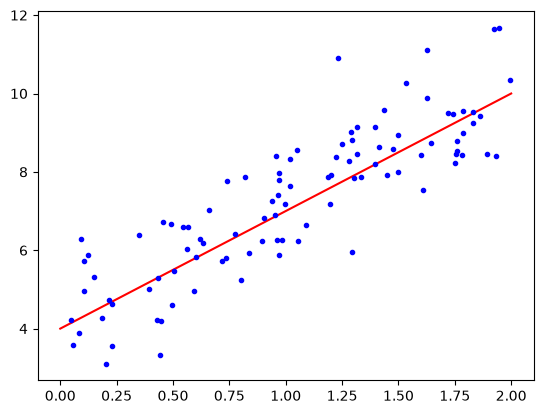

In [110]:
import matplotlib.pyplot as plt

X_true = np.array([[0,1], [2,1]]) # 
w_true = np.array([[3],[4]])
y_true = X_true @ w_true

plt.figure() 
plt.plot(X_true[:,0], y_true, "r-")
plt.plot(X,y, "b.")
plt.show()

In [122]:
dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
loader = DataLoader(dataset, batch_size=16, shuffle=True ) # shuffle = stochastic 
loss_fn = nn.MSELoss()
model = LinearRegressionNN() 
optimizer = optim.SGD(model.parameters(), lr = 1e-2)
epochs = 50 # 1 Epoche = 1 mal den gesamten Datensatz besuchen 

for epoch in range(epochs): # Training loop 
    for xb,yb in loader: # batchweise Verarbeitung 
        y_pred = model(xb) # Forward Pass 
        loss = loss_fn(y_pred,yb)
        optimizer.zero_grad() # Gradient resetten = Batches sind unabhängig 
        #
        loss.backward()
        optimizer.step()
    

model.linear.weight.item(), model.linear.bias.item()

(3.130035400390625, 4.027100086212158)

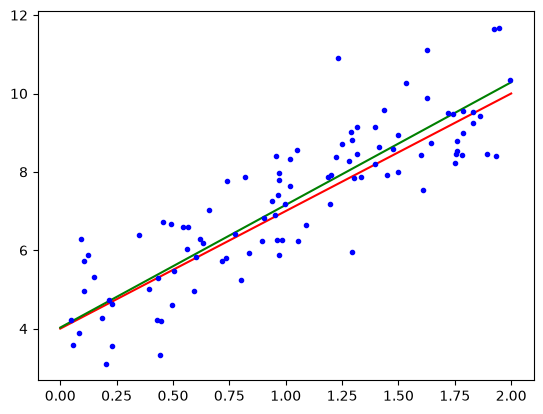

In [123]:
import matplotlib.pyplot as plt

X_true = np.array([[0,1], [2,1]]) # 
w_true = np.array([[3],[4]])
y_true = X_true @ w_true

w_torch =np.array([[model.linear.weight.item()],[model.linear.bias.item()]]) 
y_torch = X_true @ w_torch


plt.figure() 
plt.plot(X_true[:,0], y_true, "r-")
plt.plot(X_true[:,0], y_torch, "g-")

plt.plot(X,y, "b.")
plt.show()